[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-09/09-13-FGSM-Adversarial-Attack-on-MNIST.ipynb)

Train a convolutional neural network on MNIST, then use the Fast Gradient Sign Method (FGSM) to create an adversarial image that can cause the model to misclassify a correctly recognized handwritten digit. This example demonstrates gradient-based perturbation, untargeted adversarial attacks, prediction comparison, and visualization of the original image, perturbation, and adversarial result.

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 37.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.16MB/s]


Training the MNIST classifier...
Epoch [1/1], Loss: 0.2200
Training complete.

Searching for a correctly classified image of '2'...
Found a suitable image.

Original Label: 2
Original Prediction: 2 (Correct)
Adversarial Prediction: 1


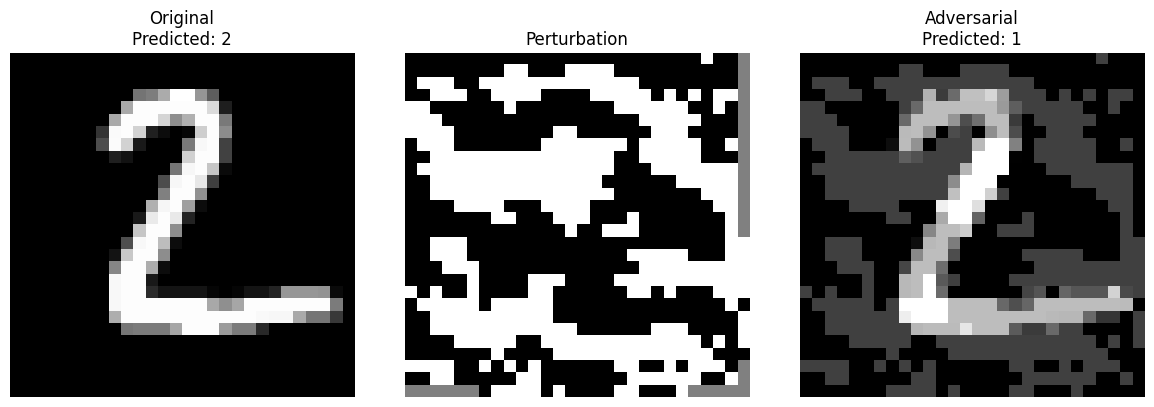

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# -------------------------------------------------------
# Self-contained FGSM example:
# 1. Train a small MNIST classifier.
# 2. Find a correctly classified digit.
# 3. Create an adversarial example.
# 4. Compare the original and adversarial predictions.
# -------------------------------------------------------

# ----------------------------
# Setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)

# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

# ----------------------------
# Model
# ----------------------------
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.fc1 = nn.Linear(4 * 4 * 32, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2, 2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = SimpleNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# Train the model
# ----------------------------
num_epochs = 1

print("Training the MNIST classifier...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    average_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}")

print("Training complete.")

# ----------------------------
# Find a correctly classified digit 2
# ----------------------------
model.eval()

image = None
original_label = None

print("\nSearching for a correctly classified image of '2'...")

for img, lbl in test_loader:
    img = img.to(device)
    lbl = lbl.to(device)

    with torch.no_grad():
        output = model(img)
        prediction = output.argmax(dim=1)

    if lbl.item() == 2 and prediction.item() == 2:
        image = img
        original_label = lbl
        print("Found a suitable image.")
        break

if image is None:
    raise RuntimeError("Could not find a correctly classified image of digit 2.")

# ----------------------------
# Create an untargeted FGSM adversarial example
# ----------------------------
# Untargeted FGSM tries to make the model wrong.
# It increases the loss for the true label.

epsilon = 0.25

image.requires_grad = True

output = model(image)
original_prediction = output.argmax(dim=1)

loss = criterion(output, original_label)

model.zero_grad()
loss.backward()

image_grad = image.grad.detach()

perturbation = epsilon * image_grad.sign()

adversarial_image = image + perturbation
adversarial_image = torch.clamp(adversarial_image, 0, 1)

with torch.no_grad():
    adversarial_output = model(adversarial_image)
    adversarial_prediction = adversarial_output.argmax(dim=1)

print(f"\nOriginal Label: {original_label.item()}")
print(f"Original Prediction: {original_prediction.item()} (Correct)")
print(f"Adversarial Prediction: {adversarial_prediction.item()}")

# ----------------------------
# Visualize original, perturbation, and adversarial image
# ----------------------------
original_np = image.detach().cpu().numpy().squeeze()
adversarial_np = adversarial_image.detach().cpu().numpy().squeeze()
perturbation_np = perturbation.detach().cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_np, cmap="gray")
axes[0].set_title(f"Original\nPredicted: {original_prediction.item()}")
axes[0].axis("off")

axes[1].imshow(perturbation_np, cmap="gray")
axes[1].set_title("Perturbation")
axes[1].axis("off")

axes[2].imshow(adversarial_np, cmap="gray")
axes[2].set_title(f"Adversarial\nPredicted: {adversarial_prediction.item()}")
axes[2].axis("off")

plt.tight_layout()
plt.show()
